# SciPAS Transport Solver — Surface Annihilation Fraction Benchmark

For a semi-infinite homogeneous medium the exact **surface annihilation
fraction** is the integral transform
$$f=\frac{\int I(z)\,e^{-z/L}\,dz}{1+L_a/L},$$
with $L$ the diffusion length and $L_a$ the surface absorption length.

A 2D color map over $(L,\,L_a)$ space shows where the FD solver reproduces this
exact result and where accuracy degrades.

** sample length.** To keep the medium effectively semi-infinite for
every grid point the sample length is scaled to the local characteristic
length of the implantation,
$$L_\mathrm{sample}= 10 L_\mathrm{profile} ,$$
where $L_\mathrm{profile}=\bar z\approx165$ nm is the depth beyond which the
10 keV Cu Makhov profile is negligible.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.constants import centi, micro, nano

from scipas.transport import (makhov_material_parameters, makhov_profile,
                              multilayer_implantation_profile, profile_solver)
from scipas.model import Material, Layer, Sample
from scipas.analysis import compute_annihilation_fractions

In [ ]:
D           = 1.0
mesh_size   = 100_000
beam_energy = 10.0        # keV

Cu_params = makhov_material_parameters().iloc[9].copy()
Cu_params['density'] = 8.96

m, n   = Cu_params['m'], Cu_params['n']
a_half = Cu_params['A_half'] * micro                                  # g/cm^2
z_half = a_half * beam_energy ** n / Cu_params['density'] * centi/nano
z_bar  = z_half / (np.log(2)) ** (1 / m)                              # nm
PROFILE_SCALE = z_bar     # 10 keV Cu profile is ~0 beyond this depth

In [3]:
N_pts  = 50
L_grid  = np.logspace(0, 6, N_pts)
La_grid = np.logspace(0, 6, N_pts)
print(f'Grid: {N_pts}x{N_pts} = {N_pts**2} points')
print(f'Sample length = max(10*max(L,La), {10*PROFILE_SCALE:.0f} nm) per grid point')

Grid: 50x50 = 2500 points
Sample length = max(10*max(L,La), 1653 nm) per grid point


### 2D scan (typically 1–2 min)

For each $(L,L_a)$ the implantation profile is recomputed on the adaptive
sample, the solver is run, and the numerical surface fraction
`compute_annihilation_fractions(...).sel(layer=-1)` is compared to $f$.
Points where $f<10^{-4}$ are skipped (relative error is meaningless when
$f\approx0$).

In [6]:
error_map = np.full((N_pts, N_pts), np.nan)

for i, La in enumerate(La_grid):
    for j, L in enumerate(L_grid):

        sample_len = 10 * PROFILE_SCALE

        depth = np.linspace(0, sample_len, 100_000)
        prof  = multilayer_implantation_profile(
            beam_energy, depth, [sample_len],
            [Cu_params], [Cu_params['density']], makhov_profile)
        x_l, y_l = prof.coords['x'].values, prof.values

        lam    = D / L**2
        layer  = Layer(width=sample_len,
                       material=Material(diffusion=D, mobility=0,
                                         bulk_annihilation_rate=lam))
        sample = Sample(layers=[layer], absorption_length=La)

        profile   = profile_solver(prof, sample, mesh_size=mesh_size)
        f_num = D*profile[0]/La
        f_ref = np.trapezoid(y_l * np.exp(-x_l / L), x_l) / (1 + La / L)

        error_map[i, j] = 100 * abs(f_num - f_ref) / f_ref

print(f'Max error: {np.nanmax(error_map):.4f}%   Median: {np.nanmedian(error_map):.5f}%')

Max error: 0.0215%   Median: 0.00001%


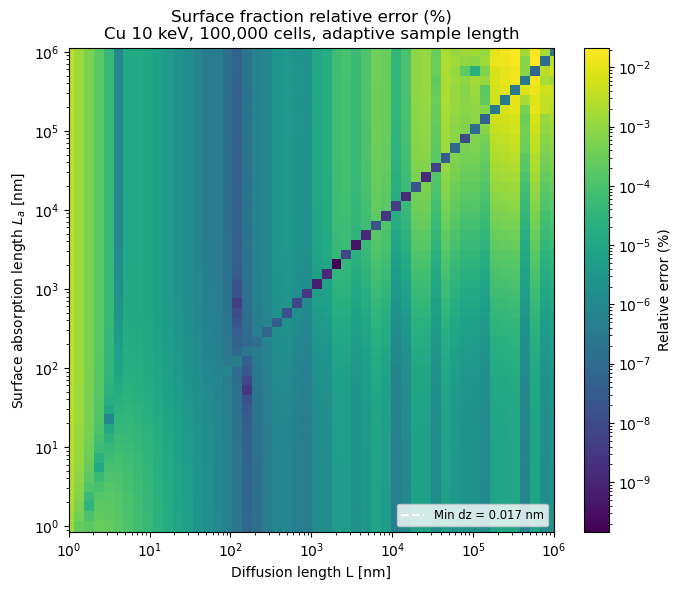

In [7]:
L_mesh, La_mesh = np.meshgrid(L_grid, La_grid)

fig, ax = plt.subplots(figsize=(7, 6))
pcm = ax.pcolormesh(L_mesh, La_mesh, error_map,
                    norm=mcolors.LogNorm(), shading='auto')
fig.colorbar(pcm, ax=ax, label='Relative error (%)')

dz_min = 10 * PROFILE_SCALE / mesh_size
ax.axvline(dz_min, color='white', ls='--', lw=1.5,
           label=f'Min dz = {dz_min:.3f} nm')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Diffusion length L [nm]')
ax.set_ylabel('Surface absorption length $L_a$ [nm]')
ax.set_title(f'Surface fraction relative error (%)\n'
             f'Cu {beam_energy:.0f} keV, {mesh_size:,} cells, adaptive sample length')
ax.set_xlim([1e0, 1e6])
ax.legend(fontsize='small', loc='lower right')
fig.tight_layout(); plt.show()